### Assignment - 4


Group Member -
1. Akarsh Dubey (CS25MTECH14001)
2. Atish Kadam (CS25MTECH14003)

**Importing Required Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

**Defining the BipartiteGraph Class for Hungarian Algorithm**

In [ ]:
INFINITY = 1e9

class BipartiteGraph:
    def __init__(self, csv_file):
        self.csv_file = csv_file
        self.left_vertices = []
        self.right_vertices = []
        self.edge_weights = {}
        self.load_from_csv()

    def load_from_csv(self):
        data = pd.read_csv(self.csv_file, header=None)
        matrix = data.values

        if matrix.shape[0] != 3:
            raise ValueError("CSV must contain exactly 3 rows")

        left_nodes = matrix[0].astype(int)
        right_nodes = matrix[1].astype(int)
        edge_costs = matrix[2].astype(float)

        self.left_vertices = sorted(int(x) for x in set(left_nodes))
        self.right_vertices = sorted(int(x) for x in set(right_nodes))


        for l, r, w in zip(left_nodes, right_nodes, edge_costs):
            key = (int(l), int(r))
            if key not in self.edge_weights:
                self.edge_weights[key] = w
            else:
                self.edge_weights[key] = min(self.edge_weights[key], w)

    def get_weight(self, left_node, right_node):
        return self.edge_weights.get((left_node, right_node), INFINITY)

    def create_cost_matrix(self):
        n_left = len(self.left_vertices)
        n_right = len(self.right_vertices)
        dim = max(n_left, n_right)

        matrix = np.full((dim, dim), INFINITY)

        for i, left_v in enumerate(self.left_vertices):
            for j, right_v in enumerate(self.right_vertices):
                matrix[i][j] = self.get_weight(left_v, right_v)

        return matrix

**Hungarian Algorithm Solver Class**

In [ ]:
class HungarianSolver:


    def __init__(self, cost_matrix):
        self.n = cost_matrix.shape[0]
        # Pad matrix with row/col of zeros for 1-indexing
        self.cost = np.zeros((self.n + 1, self.n + 1))
        self.cost[1:, 1:] = cost_matrix

        # Dual variables
        self.left_duals = np.zeros(self.n + 1)
        self.right_duals = np.zeros(self.n + 1)

        # Matching: right_match[j] = i means right_j matched to left_i
        self.right_match = np.zeros(self.n + 1, dtype=int)

        # Track dual values at each iteration
        self.dual_history = []

    def solve(self):
        "Matching through Hungarian and then returning"
        for left_idx in range(1, self.n + 1):
            self._augment_for_vertex(left_idx)
            # Save dual snapshot after processing this vertex
            self.dual_history.append((
                self.left_duals[1:].copy(),
                self.right_duals[1:].copy()
            ))

        # Convert to left-to-right mapping
        left_match = -np.ones(self.n, dtype=int)
        for right_idx in range(1, self.n + 1):
            left_idx = self.right_match[right_idx]
            if left_idx != 0 and left_idx <= self.n:
                left_match[left_idx - 1] = right_idx - 1

        return left_match

    def _augment_for_vertex(self, target_left):
        "Path finding through aurgmentation"
        # for unvisited right vertices
        slack = np.full(self.n + 1, INFINITY)
        # Parent pointers for path reconstruction
        parent = np.zeros(self.n + 1, dtype=int)
        # Visited right vertices
        visited = np.zeros(self.n + 1, dtype=bool)

        # Start from dummy right vertex 0
        self.right_match[0] = target_left
        current_right = 0

        while True:
            visited[current_right] = True
            current_left = self.right_match[current_right]
            min_slack = INFINITY
            next_right = 0

            # Update  values for all unvisited right vertices
            for right_idx in range(1, self.n + 1):
                if not visited[right_idx]:
                    # Reduced cost
                    reduced = (self.cost[current_left][right_idx] -
                             self.left_duals[current_left] -
                             self.right_duals[right_idx])

                    if reduced < slack[right_idx]:
                        slack[right_idx] = reduced
                        parent[right_idx] = current_right

                    if slack[right_idx] < min_slack:
                        min_slack = slack[right_idx]
                        next_right = right_idx

            # Update dual variables
            for j in range(self.n + 1):
                if visited[j]:
                    self.left_duals[self.right_match[j]] += min_slack
                    self.right_duals[j] -= min_slack
                else:
                    slack[j] -= min_slack

            current_right = next_right

            # Found augmenting path (unmatched right vertex)
            if self.right_match[current_right] == 0:
                break

        # Reconstruct augmenting path
        while current_right != 0:
            prev_right = parent[current_right]
            self.right_match[current_right] = self.right_match[prev_right]
            current_right = prev_right


**Function to Visualize Bipartite Graph and Matching**

In [ ]:
def visualize_graph(graph, matching=None, show_matching=False):
    " bipartite graph visualization."
    G = nx.Graph()

    left_labels = [f"L{v}" for v in graph.left_vertices]
    right_labels = [f"R{v}" for v in graph.right_vertices]

    G.add_nodes_from(left_labels, bipartite=0)
    G.add_nodes_from(right_labels, bipartite=1)

    # Add all edges
    for (l, r), w in graph.edge_weights.items():
        G.add_edge(f"L{l}", f"R{r}", weight=w)

    # Layout
    positions = {}
    for idx, label in enumerate(left_labels):
        positions[label] = (0, -idx)
    for idx, label in enumerate(right_labels):
        positions[label] = (3, -idx)

    plt.figure(figsize=(10, 6))

    # Draw nodes
    nx.draw_networkx_nodes(G, positions, nodelist=left_labels,
                          node_color='lightblue', node_size=900)
    nx.draw_networkx_nodes(G, positions, nodelist=right_labels,
                          node_color='lightgreen', node_size=900)
    nx.draw_networkx_labels(G, positions, font_size=10, font_weight='bold')

    if not show_matching:
        # Show all edges
        plt.title("Bipartite Graph - All Edges", fontsize=13)
        for u, v, data in G.edges(data=True):
            nx.draw_networkx_edges(G, positions, [(u, v)],
                                 edge_color='gray', width=1.8, alpha=0.7)
            # Position weight label
            x1, y1 = positions[u]
            x2, y2 = positions[v]
            lx = x1 + 0.25 * (x2 - x1)
            ly = y1 + 0.15 * (y2 - y1)
            plt.text(lx, ly, f"{data['weight']}", fontsize=9,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                    ha='center', va='center')
    else:
        # Show only matched edges
        plt.title("Minimum Weight Perfect Matching", fontsize=13)
        matched_edges = []
        for i, j in enumerate(matching):
            if j != -1 and j < len(graph.right_vertices):
                matched_edges.append((f"L{graph.left_vertices[i]}",
                                    f"R{graph.right_vertices[j]}"))

        for u, v in matched_edges:
            w = G[u][v]['weight']
            nx.draw_networkx_edges(G, positions, [(u, v)],
                                 edge_color='green', width=3.0, alpha=0.9)
            x1, y1 = positions[u]
            x2, y2 = positions[v]
            lx = x1 + 0.25 * (x2 - x1)
            ly = y1 + 0.15 * (y2 - y1)
            plt.text(lx, ly, f"{w}", fontsize=10, color='darkgreen',
                    fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
                    ha='center', va='center')

    plt.axis('off')
    plt.tight_layout()
    plt.show()


**Main Execution & Final Matching Output Routine**

Enter CSV filename or Path : l.csv

----------------------------------------------------------------------
FILE: l.csv
----------------------------------------------------------------------
Left vertices (A): [1, 2, 3]
Right vertices (B): [10, 11, 12]



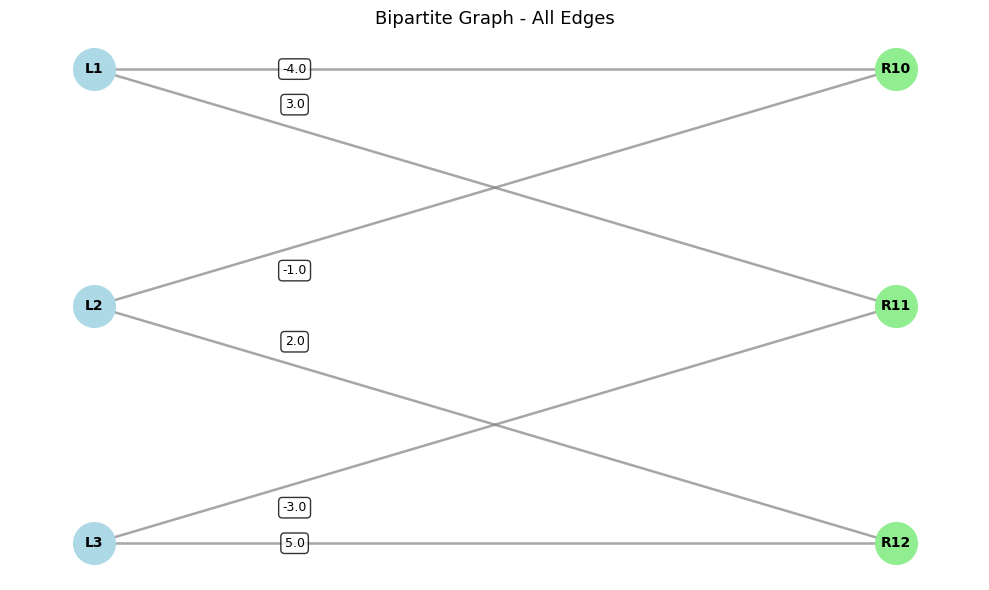

--- Iteration 1 ---
u (left potentials):  [-4.0, 0.0, 0.0]
v (right potentials): [0.0, 0.0, 0.0]

--- Iteration 2 ---
u (left potentials):  [-1.0, 2.0, 0.0]
v (right potentials): [-3.0, 0.0, 0.0]

--- Iteration 3 ---
u (left potentials):  [-1.0, 2.0, -3.0]
v (right potentials): [-3.0, 0.0, 0.0]

Final Matching (Left → Right):
  1 → 10 (weight = -4.0)
  2 → 12 (weight = 2.0)
  3 → 11 (weight = -3.0)

 Result: Minimum total matching cost = -5.0
----------------------------------------------------------------------



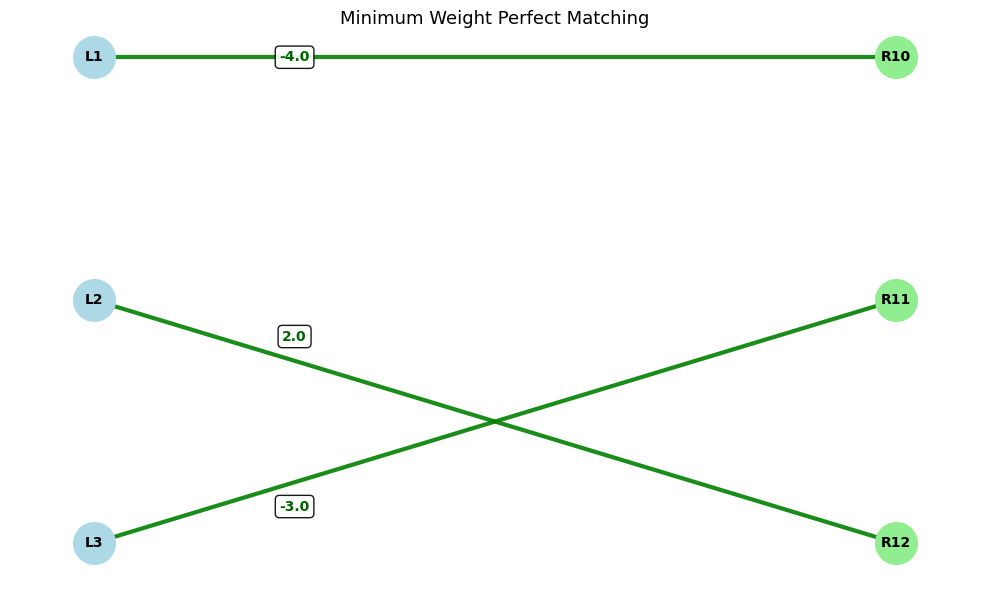

In [ ]:
def main():
    """Main execution function."""
    filename = input("Enter CSV filename or Path : ").strip()

    try:
        graph = BipartiteGraph(filename)

        print("\n" + "-" * 70)
        print(f"FILE: {filename}")
        print("-" * 70)
        print(f"Left vertices (A): {graph.left_vertices}")
        print(f"Right vertices (B): {graph.right_vertices}\n")

        # Visualize initial graph
        visualize_graph(graph, show_matching=False)

        # Solve matching
        cost_matrix = graph.create_cost_matrix()
        solver = HungarianSolver(cost_matrix)
        matching = solver.solve()

        # dual variables at each iteration
        for iteration, (left_d, right_d) in enumerate(solver.dual_history, 1):
            print(f"--- Iteration {iteration} ---")
            print(f"u (left potentials): ",
                  np.round(left_d[:len(graph.left_vertices)], 4).tolist())
            print(f"v (right potentials):",
                  np.round(right_d[:len(graph.right_vertices)], 4).tolist())
            print()

        # Output matching results
        total_weight = 0
        has_perfect_matching = True

        print("Final Matching (Left → Right):")
        for i in range(len(graph.left_vertices)):
            j = matching[i]
            left_v = graph.left_vertices[i]

            if j == -1 or j >= len(graph.right_vertices):
                print(f"  {left_v} → None")
                has_perfect_matching = False
            else:
                right_v = graph.right_vertices[j]
                weight = graph.get_weight(left_v, right_v)

                if weight >= INFINITY / 2:
                    print(f"  {left_v} → {right_v} (no valid edge)")
                    has_perfect_matching = False
                else:
                    print(f"  {left_v} → {right_v} (weight = {weight})")
                    total_weight += weight

        if has_perfect_matching:
            print(f"\n Result: Minimum total matching cost = {total_weight}")
        else:
            print("\nResult: No perfect matching exists.")

        print("-" * 70 + "\n")

        # Visualize matching
        visualize_graph(graph, matching, show_matching=True)

    except Exception as e:
        print(f"Error: {e}")


if __name__ == "__main__":
    main()